# Caracterización Lingüística para la Detección de Comentarios de Odio mediante NLP

**Autor:** Gregory Harutyunyan Gevorgyan | **Dominio:** NLP / Extracción de Características

**Resumen:**
Este proyecto desarrolla un pipeline de análisis de lenguaje natural (NLP) diseñado para extraer conclusiones estadísticas y morfológicas de un corpus masivo (>570k registros). El objetivo principal es identificar rasgos diferenciales entre el **discurso de odio** y el **discurso neutro**, facilitando la ingeniería de variables para modelos predictivos posteriores.

**Objetivos:**

* **Procesamiento de Datos a Escala:** Implementación de muestreo estratificado y limpieza avanzada de texto (normalización Unicode y corrección de *mojibake*).
* **Análisis Morfosintáctico:** Uso de `es_core_news_md` de spaCy para etiquetado POS (Part-of-Speech) y análisis de género/número.
* **Extracción de Entidades (NER):** Identificación y comparativa de entidades nombradas (Localizaciones, Organizaciones, Personas) entre clases.
* **Visualización de Datos:** Generación de un dashboard de métricas mediante `Gridspec` para sintetizar hallazgos clave.

---

## Fase 1: Ingesta de Datos y Preprocesamiento

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">1.1. Ingesta y depuración del Dataset</span>


---


Importamos las librerias necesarias y cargamos el modelo de PLN.

---



In [1]:
import pathlib # Manejo de rutas y archivos de forma moderna
import spacy # Motor de NLP
import pandas as pd # Manejo de datasets

# Instalación en el entorno para poder cargarlo
!python -m spacy download es_core_news_md 

from spacy import displacy # Visualización de resultados
import csv # Leer archivos csv a bajo nivel sin usar pandas
import es_core_news_md # _sm/_md/_lg y la más precisa en contextos es es_dep_news_trf

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/42.3 MB ? eta -:--:--
     ---------------------------------------- 0.3/42.3 MB ? eta -:--:--
      --------------------------------------- 0.8/42.3 MB 2.2 MB/s eta 0:00:20
     - -------------------------------------- 1.3/42.3 MB 2.2 MB/s eta 0:00:19
     - -------------------------------------- 1.6/42.3 MB 2.2 MB/s eta 0:00:19
     - -------------------------------------- 2.1/42.3 MB 2.2 MB/s eta 0:00:18
     -- ------------------------------------- 2.6/42.3 MB 2.1 MB/s eta 0:00:19
     -- ------------------------------------- 3.1/42.3 MB 2.2 MB/s eta 0:00:18
     --- ------------------------------------ 3.4/42.3 MB 2.2 MB/s eta 0:00:18
     --- ------------------------------------ 3.9/42.3 MB 2.1 MB/s eta 0:00:18
     ---- ----------------------------------- 4.5/42.3 MB 2.1 MB/s eta 0:00:18
     ---- ----------------------------------- 4.7/42.3 MB 2.1 MB/s 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\grego\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Cargamos el modelo:
nlp = es_core_news_md.load()

In [3]:
## Conectamos con Google Drive y definimos la ruta del fichero
# from google.colab import drive
# drive.mount('/content/drive')

filename = "../data/raw/dataset.csv"

---
Cargamos el archivo CSV en memoria como un Dataframe de pandas con la codificación de caracteres latin-1.

---



In [4]:
# Leemos el fichero y contamos cuántas filas tiene:
def cont_filas_csv(filename):
  with open(filename, 'r', encoding='utf-8', errors='ignore') as file: # Abrimos el fichero de forma eficiente
    lector = csv.reader(file, delimiter=';') # Creamos un objeto lector de csv
    next(lector, None) # Saltamos la primera fila
    num_filas = sum(1 for filas in lector) # Sumamos las filas totales
  return num_filas

filas_csv = cont_filas_csv(filename)
print(f"Numero de filas en el csv: {filas_csv}")

Numero de filas en el csv: 575029


In [5]:
data = pd.read_csv(filename, delimiter=";", encoding='latin-1')

C:\Users\grego\AppData\Local\Temp\ipykernel_11868\3854135399.py:1: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filename, delimiter=";", encoding='latin-1')


In [6]:
print("Primeras filas del corpus original:")
data.head()

Primeras filas del corpus original:


,MEDIO,SOPORTE,URL,TIPO DE MENSAJE,CONTENIDO A ANALIZAR,INTENSIDAD,TIPO DE ODIO,TONO HUMORISTICO,MODIFICADOR,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,EL PAÍS,WEB,URL_a4d7efc0,COMENTARIO,el barí§a nunca acaeza ante un segundo b ni an...,3.0,Otros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EL PAÍS,WEB,URL_a4d7efc0,COMENTARIO,el real madrid ha puesto punto y final a su an...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EL PAÍS,WEB,URL_54312d9e,COMENTARIO,cristina cifuentes podrí­a haber sido la presi...,3.0,Ideológico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EL PAÍS,WEB,URL_54312d9e,COMENTARIO,habrí­a que reabrir el caso. el supremo se ded...,3.0,Ideológico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EL PAÍS,WEB,URL_54312d9e,COMENTARIO,me parece un poco exagerado pedir más de tres ...,3.0,Ideológico,Si,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
El dataset contiene columnas irrelevantes para esta actividad. Procederemos a eliminarlas para simplificar el coste computacional.


---




In [7]:
# Reducimos el dataset a las columnas que nos interesan
data_reducido = data.drop(data.columns[[0,1,2]], axis=1).drop(data.columns[7:], axis=1)

In [8]:
print("Primeras filas del corpus reducido:")
data_reducido.head(10)

Primeras filas del corpus reducido:


,TIPO DE MENSAJE,CONTENIDO A ANALIZAR,INTENSIDAD,TIPO DE ODIO
0,COMENTARIO,el barí§a nunca acaeza ante un segundo b ni an...,3.0,Otros
1,COMENTARIO,el real madrid ha puesto punto y final a su an...,0.0,NaN
2,COMENTARIO,cristina cifuentes podrí­a haber sido la presi...,3.0,Ideológico
3,COMENTARIO,habrí­a que reabrir el caso. el supremo se ded...,3.0,Ideológico
4,COMENTARIO,me parece un poco exagerado pedir más de tres ...,3.0,Ideológico
5,COMENTARIO,parece que todos los delincuentes niegan las e...,3.0,Ideológico
6,COMENTARIO,"preguntárselo al fracasado, media carrera en 6...",4.0,Ideológico
7,COMENTARIO,tenemos aí±os para ver a esta asociación delic...,3.0,Ideológico
8,COMENTARIO,"una ""fardera"" como presidenta de la comunidad ...",4.0,Ideológico
9,COMENTARIO,uno a uno tienen que ir cayendo frente a la ju...,3.0,Ideológico


### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">1.2. Limpieza del Dataset</span>



---

El corpus proporcionado contiene textos de distintas fuentes y presenta errores de codificación y ruido tipográfico. Para garantizar un análisis adecuado, se ha aplicado un proceso de limpieza y normalización.

---



In [9]:
import unicodedata
import re

reemplazos_concretos = {
    "í§": "ç",
    "í¼": "ü",
    "í±": "ñ",
    "í¡": "á",
    "í©": "é",
    "í³": "ó",
    "íº": "ú",
}

def correcion_especifica(texto):
    if not isinstance(texto, str):
        return texto
    for k, v in reemplazos_concretos.items():
        texto = texto.replace(k, v)
    return texto



def limpieza(texto):
    if not isinstance(texto, str):
        return texto

    # 1. Reparar mojibake UTF-8
    try:
        texto = texto.encode("latin1").decode("utf-8")
    except:
        pass

    # 2. Reparar corrupciones cp1252/latin-1
    texto = correcion_especifica(texto)

    # 3. Normalizar
    texto = unicodedata.normalize("NFKC", texto)

    # 4. Limpiar basura residual
    texto = re.sub(
        r"[^a-zA-Z0-9áéíóúÁÉÍÓÚñÑçüÇÜ.,;:!?¿¡()\"' /-]+",
        "",
        texto
    )

    return texto

data_limpio = data_reducido.copy()

for col in data_limpio.columns:
    if data_limpio[col].dtype == object:
      data_limpio[col] = data_limpio[col].apply(limpieza)

In [10]:
# Verificamos que han habido cambios:
cambios = (data_reducido != data_limpio).sum()
cambios

TIPO DE MENSAJE            273
CONTENIDO A ANALIZAR    369059
INTENSIDAD                 399
TIPO DE ODIO            562736
dtype: int64

In [11]:
# Hallamos el número de filas de cada columna con valores faltantes
x = data_limpio["TIPO DE MENSAJE"].isna().sum()
y = data_limpio["CONTENIDO A ANALIZAR"].isna().sum()
z = data_limpio["INTENSIDAD"].isna().sum()

print(f"El numero de filas que contienen valores faltantes en la columna TIPO DE MENSAJE es: {x}")
print(f"El numero de filas que contienen valores faltantes en la columna CONTENIDO A ANALIZAR es: {y}")
print(f"El numero de filas que contienen valores faltantes en la columna INTENSIDAD es: {z}")

El numero de filas que contienen valores faltantes en la columna TIPO DE MENSAJE es: 262
El numero de filas que contienen valores faltantes en la columna CONTENIDO A ANALIZAR es: 268
El numero de filas que contienen valores faltantes en la columna INTENSIDAD es: 399


---
Debido a que el número de filas que contienen valores faltantes es insignificante en comparación al conjunto total de los datos, podemos eliminar esas filas sin problema.

---




In [12]:
# Limpiamos esas filas
data_limpio = data_limpio.dropna(subset=["INTENSIDAD"])

In [13]:
print("Primeras filas del dataset final limpio:")
data_limpio.head(10)

Primeras filas del dataset final limpio:


,TIPO DE MENSAJE,CONTENIDO A ANALIZAR,INTENSIDAD,TIPO DE ODIO
0,COMENTARIO,el barça nunca acaeza ante un segundo b ni ant...,3.0,Otros
1,COMENTARIO,el real madrid ha puesto punto y final a su an...,0.0,NaN
2,COMENTARIO,cristina cifuentes podría haber sido la presid...,3.0,Ideológico
3,COMENTARIO,habría que reabrir el caso. el supremo se dedi...,3.0,Ideológico
4,COMENTARIO,me parece un poco exagerado pedir más de tres ...,3.0,Ideológico
5,COMENTARIO,parece que todos los delincuentes niegan las e...,3.0,Ideológico
6,COMENTARIO,"preguntárselo al fracasado, media carrera en 6...",4.0,Ideológico
7,COMENTARIO,tenemos años para ver a esta asociación delict...,3.0,Ideológico
8,COMENTARIO,"una ""fardera"" como presidenta de la comunidad ...",4.0,Ideológico
9,COMENTARIO,uno a uno tienen que ir cayendo frente a la ju...,3.0,Ideológico


<hr>
Guardamos el dataset limpio en memoria local
<hr>

In [14]:
data_limpio.to_csv('../data/processed/dataset_cleaned.csv', index=False)

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">1.3. Submuestreo manteniendo las proporciones relevantes.</span>

---
Para la realización de la actividad supone mucho coste de tiempo usar el dataset en su totalidad. Por lo tanto, nos reduciremos a un subconjunto que mantenga las proporciones de las variables analizar para que la submuestra sea representativa.

---

In [15]:
lineas_submuestra = 40000

In [16]:
# Creamos un diccionario con el numero de TIPO DE MENSAJE teniendo en cuenta sin odio y con odio
def fun_num_mensajes(df):
  mensajes_sin_odio = df[df["INTENSIDAD"] == 0.0]["TIPO DE MENSAJE"].value_counts()
  mensajes_con_odio = df[df["INTENSIDAD"] != 0.0]["TIPO DE MENSAJE"].value_counts()

  tipo_mensaje = {
      "COMENTARIO": [int(mensajes_sin_odio.get("COMENTARIO",0)), int(mensajes_con_odio.get("COMENTARIO",0))],
      "NOTICIA": [int(mensajes_sin_odio.get("NOTICIA",0)), int(mensajes_con_odio.get("NOTICIA",0))],
      "TITULAR NOTICIA": [int(mensajes_sin_odio.get("TITULAR NOTICIA",0)), int(mensajes_con_odio.get("TITULAR NOTICIA",0))]
      }
  return tipo_mensaje

tipo_mensaje = fun_num_mensajes(data_limpio)

print("Número de cada TIPO DE MENSAJE:[sin_odio, con_odio]:")
tipo_mensaje

Número de cada TIPO DE MENSAJE:[sin_odio, con_odio]:


{'COMENTARIO': [323697, 10621],
 'NOTICIA': [157843, 1570],
 'TITULAR NOTICIA': [80793, 105]}

In [17]:
# Creamos una función que devuelva las proporciones de cada tipo de mensaje
def fun_proporciones(df,tipo_mensaje):
  num_lineas = df.shape[0]
  # Hallamos las proporciones de cada TIPO DE MENSAJE
  prop_comentario = [tipo_mensaje['COMENTARIO'][0] / num_lineas, tipo_mensaje['COMENTARIO'][1] / num_lineas]
  prop_noticia = [tipo_mensaje['NOTICIA'][0] / num_lineas, tipo_mensaje['NOTICIA'][1] / num_lineas]
  prop_titular = [tipo_mensaje['TITULAR NOTICIA'][0] / num_lineas, tipo_mensaje['TITULAR NOTICIA'][1] / num_lineas]

  # Creamos el diccionario de las proporciones
  proporciones = {
      "COMENTARIO": prop_comentario,
      "NOTICIA": prop_noticia,
      "TITULAR NOTICIA": prop_titular
      }
  return proporciones

proporciones = fun_proporciones(data_limpio, tipo_mensaje)

print("Proporciones de cada TIPO DE MENSAJE: [sin_odio, con_odio]:")
proporciones

Proporciones de cada TIPO DE MENSAJE: [sin_odio, con_odio]:


{'COMENTARIO': [0.5633137845222143, 0.018483197883855697],
 'NOTICIA': [0.27468631989280057, 0.002732192889337487],
 'TITULAR NOTICIA': [0.14060003828550546, 0.00018272627603849433]}

In [18]:
# Definimos la función para extraer una submuestra manteniendo las proporciones
def extrac_con_proporciones(df, filas, prop):
  # Calculamos el número de filas de cada tipo de mensaje:
  f_comentarios = [
      int(filas*prop["COMENTARIO"][0]),
      int(filas*prop["COMENTARIO"][1])
      ]
  f_noticia = [
      int(filas*prop["NOTICIA"][0]),
      int(filas*prop["NOTICIA"][1])
      ]
  f_titular = [
      int(filas*prop["TITULAR NOTICIA"][0]),
      int(filas*prop["TITULAR NOTICIA"][1])
      ]

  # Generamos las partes de la submuestra final del dataframe original
  df_comentarios_sin_odio = df[(df["TIPO DE MENSAJE"] == "COMENTARIO") & (df["INTENSIDAD"] == 0.0)].sample(n = f_comentarios[0], random_state = 8)
  df_comentarios_con_odio = df[(df["TIPO DE MENSAJE"] == "COMENTARIO") & (df["INTENSIDAD"] != 0.0)].sample(n = f_comentarios[1], random_state = 8)
  df_noticias_sin_odio = df[(df["TIPO DE MENSAJE"] == "NOTICIA") & (df["INTENSIDAD"] == 0.0)].sample(n = f_noticia[0], random_state = 8)
  df_noticias_con_odio = df[(df["TIPO DE MENSAJE"] == "NOTICIA") & (df["INTENSIDAD"] != 0.0)].sample(n = f_noticia[1], random_state = 8)
  df_titular_sin_odio = df[(df["TIPO DE MENSAJE"] == "TITULAR NOTICIA") & (df["INTENSIDAD"] == 0.0)].sample(n = f_titular[0], random_state = 8)
  df_titular_con_odio = df[(df["TIPO DE MENSAJE"] == "TITULAR NOTICIA") & (df["INTENSIDAD"] != 0.0)].sample(n = f_titular[1], random_state = 8)

  return pd.concat([df_comentarios_sin_odio,
                    df_comentarios_con_odio,
                    df_noticias_sin_odio,
                    df_noticias_con_odio,
                    df_titular_sin_odio,
                    df_titular_con_odio], ignore_index=True)

sub_data = extrac_con_proporciones(data_limpio, lineas_submuestra, proporciones)

sub_data.shape[0]


39998

---
Una vez extraída la submuestra comprobamos antes que mantiene las proporciones establecidas.

---

In [19]:
tipo_mensaje_sub = fun_num_mensajes(sub_data)

proporciones_sub = fun_proporciones(sub_data, tipo_mensaje_sub)

print("Proporciones de la submuestra de cada TIPO DE MENSAJE:[sin_odio, con_odio]:")
proporciones_sub


Proporciones de la submuestra de cada TIPO DE MENSAJE:[sin_odio, con_odio]:


{'COMENTARIO': [0.5633281664083204, 0.01847592379618981],
 'NOTICIA': [0.2746887344367218, 0.0027251362568128405],
 'TITULAR NOTICIA': [0.1406070303515176, 0.00017500875043752187]}

In [20]:
sub_data.head(10)

,TIPO DE MENSAJE,CONTENIDO A ANALIZAR,INTENSIDAD,TIPO DE ODIO
0,COMENTARIO,USUARIOOFUSCADO USUARIOOFUSCADO USUARIOOFUSCAD...,0.0,NaN
1,COMENTARIO,haciendo campaña publicitaria...se ve que este...,0.0,NaN
2,COMENTARIO,tambin había premio de literatura juvenil en c...,0.0,NaN
3,COMENTARIO,"sin embargo tu, terrazas a tope, bares a tope,...",0.0,NaN
4,COMENTARIO,"si me votáis, volveré a sacrificarme por vosot...",0.0,NaN
5,COMENTARIO,unidas podemos son unos analfabetos incapaces ...,0.0,NaN
6,COMENTARIO,en irak las mujeres ya pueden conducir coches ...,0.0,NaN
7,COMENTARIO,falta valentía en muchos votantes catalanes pa...,0.0,NaN
8,COMENTARIO,pues yo era de los que tenía ganas de poder ap...,0.0,NaN
9,COMENTARIO,pero ésto qué cachondeo es??,0.0,NaN


<hr>
Guardamos la submuestra del dataset limpio en local
<hr>

In [21]:
sub_data.to_csv('../data/processed/sub_dataset_cleaned.csv', index=False)

## Fase 2: Análisis Morfosintáctico y Extracción de Features

---
A partir de ahora, usaremos la submuestra establecida del corpus.

---

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.1. ¿Cuántos registros contiene el corpus?</span>

In [22]:
registros = data_limpio.shape[0]
registros_sub = sub_data.shape[0]

print(f"El corpus original contiene {registros} registros")
print(f"La submuestra extraída del corpus original contiene {registros_sub} registros")

El corpus original contiene 574630 registros
La submuestra extraída del corpus original contiene 39998 registros


<hr>
Aunque la submuestra extraída del corpus original es considerablemente más pequeña, mantiene las proporciones de las variables que se estudiarán en las actividades. De este modo, se obtiene un conjunto de datos representativo del corpus original, lo que permite reducir significativamente el gran coste computacional que supone para mi equipo emplear el dataset completo.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.2. ¿Cuántas palabras totales hay en los comentarios del corpus?</span>

In [23]:
# Inicializamos la variable del conteo de palabras de los comentarios
conteo_pal_com = 0

# Inicializamos la variable del conteo de palabras totales
conteo_total = 0

# Fijamos el número de filas
num_filas = sub_data.shape[0]

# Realizamos un bucle simple para el conteo de palabras de los comentarios y el conteo de palabras totales
for i in range(num_filas):

  # Aseguramos que sea tipo string la celda
  texto = str(sub_data.loc[i,"CONTENIDO A ANALIZAR"])
  doc = nlp(texto)

  # Fijamos el conteo de palabras a 0 y contamos
  num_tokens_alpha = 0
  for token in doc:
    if token.is_alpha:
      num_tokens_alpha = num_tokens_alpha + 1

  # Sumamos al conteo total
  conteo_total = conteo_total + num_tokens_alpha

  # Sumamos al conteo de palabras de comentarios si es un comentario
  if(sub_data.loc[i, "TIPO DE MENSAJE"] == "COMENTARIO"):
    conteo_pal_com = conteo_pal_com + num_tokens_alpha

print(f"En los comentarios del corpus hay un total de {conteo_pal_com} palabras de las {conteo_total} palabras totales.")
print(f"Las palabras en los comentarios suponen el {conteo_pal_com*100/conteo_total:.2f}% de las totales")

En los comentarios del corpus hay un total de 1089728 palabras de las 4212432 palabras totales.
Las palabras en los comentarios suponen el 25.87% de las totales


<hr>
La palabras en comentarios representan alrededor del 26 % de las palabras totales del contenido a analizar. Es decir, aporximadamente una cuarta parte de todas las palabras provienen de comentarios, lo cual es un dato relevante a tener en cuenta en el análisis.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.3. ¿Cuál el número promedio de palabras en cada comentario?</span>

In [24]:
# Fijamos el numero de comentarios
num_comentarios = sub_data['TIPO DE MENSAJE'].value_counts()['COMENTARIO']

print(f"El promedio de palabras en cada comentario es de {round(conteo_pal_com/num_comentarios)} palabras")

El promedio de palabras en cada comentario es de 47 palabras


<hr>
Una longitud media de 47 palabras se considera suficiente para afirmar que los comentarios no constituyen textos breves. En consecuencia, la intensidad de odio detectada en cada uno de ellos resulta más representativa, ya que es menos probable que se interpreten de forma incorrecta las intenciones del autor. En comentarios más cortos podría introducirse un mayor sesgo interpretativo, al estar menos contextualizados.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.4. Considerando dos grupos de comentarios (odio y no odio) ¿Cuál el número promedio de palabras en los comentarios de cada grupo?</span>

In [25]:
# Inicializamos la variable del conteo de palabras de los comentarios sin odio
conteo_sin_odio = 0

# Inicializamos la variable del conteo de palabras de los comentarios con odio
conteo_con_odio = 0

# Realizamos un bucle para el conteo de las palabras
for i in range(num_filas):

  # Aseguramos que es tipo string la celda
  texto = str(sub_data.loc[i,"CONTENIDO A ANALIZAR"])
  doc = nlp(texto)

  # Fijamos el conteo de palabras a 0 y contamos
  num_tokens_alpha = 0
  for token in doc:
    if token.is_alpha:
      num_tokens_alpha += 1

  # Sumamos al conteo correspondiente
  if(sub_data.loc[i, "TIPO DE MENSAJE"] == "COMENTARIO" and sub_data.loc[i,"INTENSIDAD"] == 0):
    conteo_sin_odio += num_tokens_alpha
  elif(sub_data.loc[i, "TIPO DE MENSAJE"] == "COMENTARIO" and sub_data.loc[i,"INTENSIDAD"] > 0):
    conteo_con_odio += num_tokens_alpha

total_sin_odio = sub_data[(sub_data["TIPO DE MENSAJE"] == "COMENTARIO") & (sub_data["INTENSIDAD"] == 0.0)].shape[0]
total_con_odio = sub_data[(sub_data["TIPO DE MENSAJE"] == "COMENTARIO") & (sub_data["INTENSIDAD"] != 0.0)].shape[0]

promedio_pal_sin = conteo_sin_odio / total_sin_odio if total_sin_odio > 0 else 0
promedio_pal_con = conteo_con_odio / total_con_odio if total_con_odio > 0 else 0

print(f"El promedio de palabras en comentarios sin odio es de {round(promedio_pal_sin, 2)} palabras")
print(f"El promedio de palabras en comentarios con odio es de {round(promedio_pal_con, 2)} palabras")

El promedio de palabras en comentarios sin odio es de 47.85 palabras
El promedio de palabras en comentarios con odio es de 15.57 palabras


<hr>
Los comentarios con odio se expresan, de media, en textos más breves. Los comentarios más extensos tienden a estar menos asociado a la presencia de odio en el corpus. Podemos deducir con estos datos, y teniendo en cuenta que el promedio de palabras sin distinción entre odio/no odio es de 47, que la gran parte de los comentarios no contienen odio.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.5. Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el número promedio de oraciones en los comentarios de cada grupo?</span>

In [26]:
# Inicializamos contadores de oraciones y de comentarios por tipo de odio
conteo_orac_sin_odio = 0
conteo_orac_con_odio = 0
num_comentarios_sin = 0
num_comentarios_con = 0

# Realizamos un bucle para el conteo de las oraciones
for i in range(num_filas):

  # Aseguramos que es tipo string la celda
  texto = str(sub_data.loc[i,"CONTENIDO A ANALIZAR"])
  doc = nlp(texto)

  if(sub_data.loc[i, "TIPO DE MENSAJE"] == "COMENTARIO" and sub_data.loc[i,"INTENSIDAD"] == 0):
    conteo_orac_sin_odio += len(list(doc.sents))
    num_comentarios_sin += 1
  elif(sub_data.loc[i, "TIPO DE MENSAJE"] == "COMENTARIO" and sub_data.loc[i,"INTENSIDAD"] > 0):
    conteo_orac_con_odio += len(list(doc.sents))
    num_comentarios_con += 1

promedio_orac_sin = conteo_orac_sin_odio / num_comentarios_sin if num_comentarios_sin > 0 else 0
promedio_orac_con = conteo_orac_con_odio / num_comentarios_con if num_comentarios_con > 0 else 0

print(f"Promedio de oraciones por comentario sin odio: {promedio_orac_sin:.2f}")
print(f"Promedio de oraciones por comentario con odio: {promedio_orac_con:.2f}")

Promedio de oraciones por comentario sin odio: 2.26
Promedio de oraciones por comentario con odio: 1.51


<hr>
La diferencia observada en la conclusión anterior se presenta también en el número de oraciones de los comentarios, lo que refuerza dicha afirmación.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">2.6. Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de palabras en cada combinación posible de género y número (p.ej. masculino singular) en cada grupo?</span>

In [27]:
conteo_gn_sin_odio = {
    ("Masc", "Sing"): 0,
    ("Masc", "Plur"): 0,
    ("Fem", "Sing"): 0,
    ("Fem", "Plur"): 0
}

conteo_gn_con_odio = {
    ("Masc", "Sing"): 0,
    ("Masc", "Plur"): 0,
    ("Fem", "Sing"): 0,
    ("Fem", "Plur"): 0
}

total_sin_odio = 0
total_con_odio = 0

# Número de filas 
num_filas = sub_data.shape[0]

# Bucle principal
for i in range(num_filas):

    # Solo analizamos comentarios
    if sub_data.loc[i, "TIPO DE MENSAJE"] != "COMENTARIO":
        continue

    texto = str(sub_data.loc[i, "CONTENIDO A ANALIZAR"])
    doc = nlp(texto)
    
    intensidad = sub_data.loc[i, "INTENSIDAD"]

    for ent in doc.ents:
        for token in ent:

            if token.pos_ not in {"NOUN", "PROPN", "ADJ", "DET", "PRON"}:
                continue

            genero = token.morph.get("Gender") # El get devuelve una lista
            numero = token.morph.get("Number") # El get devuelve una lista

            if genero and numero:
                clave = (genero[0], numero[0]) 

                if intensidad == 0:
                    conteo_gn_sin_odio[clave] += 1
                    total_sin_odio += 1
                elif intensidad > 0:
                    conteo_gn_con_odio[clave] += 1
                    total_con_odio += 1

# Resultados
print("Las proporciones de género y número en entidades NER de comentarios son:")

for clave, valor in conteo_gn_sin_odio.items():
    genero, numero = clave
    print(f"  {genero} {numero} en comentarios sin odio: {valor} ({valor/sum(conteo_gn_sin_odio.values())*100:.2f}%)")

print(f" Total sin odio: {total_sin_odio}")
for clave, valor in conteo_gn_con_odio.items():
    genero, numero = clave
    print(f"  {genero} {numero} en comentarios con odio: {valor} ({valor/sum(conteo_gn_con_odio.values())*100:.2f}%)")

print(f" Total con odio: {total_con_odio}")

Las proporciones de género y número en entidades NER de comentarios son:
  Masc Sing en comentarios sin odio: 3882 (43.08%)
  Masc Plur en comentarios sin odio: 812 (9.01%)
  Fem Sing en comentarios sin odio: 3769 (41.83%)
  Fem Plur en comentarios sin odio: 548 (6.08%)
 Total sin odio: 9011
  Masc Sing en comentarios con odio: 53 (35.81%)
  Masc Plur en comentarios con odio: 16 (10.81%)
  Fem Sing en comentarios con odio: 73 (49.32%)
  Fem Plur en comentarios con odio: 6 (4.05%)
 Total con odio: 148


<hr>
Los comentarios se expresan mayormente en singular; sin embargo, se puede observar que en los comentarios con odio predomina ligeramente el uso del género femenino.  

## Fase 3: Reconocimiento de Entidades Nombradas (NER)

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">3.1. Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER en cada grupo?</span>

In [28]:
# Inicializamos contadores
comentarios_sin_odio = 0
comentarios_con_odio = 0
comentarios_sin_odio_ner = 0
comentarios_con_odio_ner = 0

# Número de filas
num_filas = sub_data.shape[0]

# Bucle principal
for i in range(num_filas):

    # Solo analizamos comentarios
    if sub_data.loc[i, "TIPO DE MENSAJE"] != "COMENTARIO":
        continue

    texto = str(sub_data.loc[i, "CONTENIDO A ANALIZAR"])
    doc = nlp(texto)

    tiene_ner = len(doc.ents) > 0

    # Comentarios sin odio
    if sub_data.loc[i, "INTENSIDAD"] == 0:
        comentarios_sin_odio += 1
        if tiene_ner:
            comentarios_sin_odio_ner += 1

    # Comentarios con odio
    elif sub_data.loc[i, "INTENSIDAD"] > 0:
        comentarios_con_odio += 1
        if tiene_ner:
            comentarios_con_odio_ner += 1

# Cálculo de porcentajes
porc_sin_odio = (comentarios_sin_odio_ner / comentarios_sin_odio) * 100
porc_con_odio = (comentarios_con_odio_ner / comentarios_con_odio) * 100

print(f"Porcentaje de comentarios sin odio con entidades NER: {porc_sin_odio:.2f}%")
print(f"Porcentaje de comentarios con odio con entidades NER: {porc_con_odio:.2f}%")


Porcentaje de comentarios sin odio con entidades NER: 42.88%
Porcentaje de comentarios con odio con entidades NER: 33.96%


<hr>
El reconocimiento de entidades nombradas (NER) es una técnica de procesamiento del lenguaje natural que identifica y clasifica automáticamente menciones a entidades del mundo real dentro del texto (persona, lugar, organización...).

En nuestro caso, el 42.88 % de los comentarios sin odio presenta al menos una entidad NER y el 33.96 % de los comentarios con odio presenta al menos una entidad NER, es decir, los comentarios sin odio presentan entidades NER con mayor frecuencia.

Podemos interpretar estos resultados concluyendo:
- El discurso no odioso tiende más a hablar de personas concretas y mencionar organizaciones, lugares, hechos...
- El discurso odioso es más genérico, usa más insultos, adjetivos, y no necesita referirse a entidades nombradas.

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">3.2. Considerando dos grupos de comentarios (odio y no odio) ¿Cuál es el porcentaje de comentarios que contienen entidades NER de tipo PERSON, ORG, LOC y NORP en cada grupo?</span>

In [29]:
# Inicializamos contadores
conteo_ner_sin_odio = {
    "PER": 0,
    "LOC": 0,
    "ORG": 0,
    "NORP": 0,
    "Total": 0 # OJO: el total no es de este diccionario, es la suma total de todas la entidades que se cuentan (pueden no ser estas cuatro)
}

conteo_ner_con_odio = {
    "PER": 0,
    "LOC": 0,
    "ORG": 0,
    "NORP": 0,
    "Total": 0 # OJO: el total no es de este diccionario, es la suma total de todas la entidades que se cuentan (pueden no ser estas cuatro)
}

# Número de filas
num_filas = sub_data.shape[0]

# Bucle principal
for i in range(num_filas):

    # Solo analizamos comentarios
    if sub_data.loc[i, "TIPO DE MENSAJE"] != "COMENTARIO":
        continue

    texto = str(sub_data.loc[i, "CONTENIDO A ANALIZAR"])
    doc = nlp(texto)

    intensidad = sub_data.loc[i, "INTENSIDAD"]

    if intensidad == 0:
        conteo = conteo_ner_sin_odio
    elif intensidad > 0:
        conteo = conteo_ner_con_odio
    else:
        continue

    for ent in doc.ents:
        conteo["Total"] += 1
        
        if ent.label_ in conteo:
            conteo[ent.label_] += 1

# Resultados
print("Las proporciones de entidades NER en comentarios sin odio son:")
for clave, valor in conteo_ner_sin_odio.items():
    if clave != "Total":
        print(f"  {clave}: {valor} ({valor/conteo_ner_sin_odio['Total']*100:.2f}%)")
print(f"  Total: {conteo_ner_sin_odio['Total']}")

print("Las proporciones de entidades NER en comentarios con odio son:")
for clave, valor in conteo_ner_con_odio.items():
    if clave != "Total":
        print(f"  {clave}: {valor} ({valor/conteo_ner_con_odio['Total']*100:.2f}%)")
print(f"  Total: {conteo_ner_con_odio['Total']}")

Las proporciones de entidades NER en comentarios sin odio son:
  PER: 9739 (32.99%)
  LOC: 12783 (43.30%)
  ORG: 3956 (13.40%)
  NORP: 0 (0.00%)
  Total: 29523
Las proporciones de entidades NER en comentarios con odio son:
  PER: 143 (43.60%)
  LOC: 88 (26.83%)
  ORG: 50 (15.24%)
  NORP: 0 (0.00%)
  Total: 328


<hr>
En los comentarios sin odio predominan ligeramente las entidades de localización frente a las de persona, lo que sugiere un discurso más contextualizado. En cambio, en los comentarios con odio se observa una mayor proporción relativa de entidades de persona respecto a las de localización. En consecuencia, podemos inferir que, cuando se emplean entidades nombradas, los comentarios odiosos tienden a dirigirse a individuos concretos.

## Fase 4: Análisis Estadístico y Densidad Léxica

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">4.1. Considerando dos grupos de comentarios (odio y no odio) ¿Cuáles son los 100 lemas más repetidos en los comentarios de cada grupo.</span>

In [30]:
from collections import Counter
from tabulate import tabulate

lemas_sin_odio = Counter() # Diccionario especializado para contar
lemas_con_odio = Counter() # Diccionario especializado para contar

num_filas = sub_data.shape[0]

for i in range(num_filas):

    if sub_data.loc[i, "TIPO DE MENSAJE"] != "COMENTARIO":
        continue

    texto = str(sub_data.loc[i, "CONTENIDO A ANALIZAR"])
    doc = nlp(texto)

    intensidad = sub_data.loc[i, "INTENSIDAD"]

    if intensidad == 0:
        contador_lemas = lemas_sin_odio
    elif intensidad > 0:
        contador_lemas = lemas_con_odio
    else:
        continue

    for token in doc:
        if token.is_alpha and not token.is_stop:
            contador_lemas[token.lemma_.lower()] += 1

top_100_sin_odio = lemas_sin_odio.most_common(100)
top_100_con_odio = lemas_con_odio.most_common(100)


In [31]:
# Mostramos los resultados en tablas
tabla =[]

total_top100_sin_odio = sum(frec for _, frec in top_100_sin_odio)
total_top100_con_odio = sum(frec for _, frec in top_100_con_odio)

for i in range(min(len(top_100_sin_odio), len(top_100_con_odio))):
    lema_s, freq_s = top_100_sin_odio[i]
    lema_c, freq_c = top_100_con_odio[i]

    frel_s = freq_s / total_top100_sin_odio
    frel_c = freq_c / total_top100_con_odio

    tabla.append([lema_s, freq_s, f"{frel_s*100:.2f}%", lema_c, freq_c, f"{frel_c*100:.2f}%"])
    

In [32]:
# Guardamos el archivo de frecuencias en un csv
import os

output_dir = "../reports/tables"
os.makedirs(output_dir, exist_ok=True)

df_frecuencias = pd.DataFrame(tabla, columns=[
    "lema_sin_odio", "frec_sin_odio", "frel_sin_odio", 
    "lema_con_odio", "frec_con_odio", "frel_con_odio"
])

# Usamos index=False para no añadir una columna de IDs innecesaria
# Usamos encoding='utf-8-sig' para que Excel lo abra bien con tildes y eñes
csv_path = os.path.join(output_dir, "analisis_frecuencias_top100.csv")
df_frecuencias.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"Dataset de frecuencias exportado para uso técnico en: {csv_path}")

Dataset de frecuencias exportado para uso técnico en: ../reports/tables\analisis_frecuencias_top100.csv


In [33]:
print(tabulate(
    tabla,
    headers=["Lema sin odio", "Frecuencia sin odio", "Frecuencia relativa sin odio", "Lema con odio", "Frecuencia con odio", "Frecuencia relativa con odio"],
    tablefmt="github"
))

| Lema sin odio    |   Frecuencia sin odio | Frecuencia relativa sin odio   | Lema con odio    |   Frecuencia con odio | Frecuencia relativa con odio   |
|------------------|-----------------------|--------------------------------|------------------|-----------------------|--------------------------------|
| usuarioofuscado  |                  4475 | 5.80%                          | usuarioofuscado  |                    89 | 6.10%                          |
| año              |                  2277 | 2.95%                          | mierda           |                    60 | 4.11%                          |
| gobierno         |                  2007 | 2.60%                          | puta             |                    49 | 3.36%                          |
| persona          |                  1679 | 2.17%                          | hijo             |                    35 | 2.40%                          |
| españa           |                  1572 | 2.04%                          

<hr>
En comentarios sin odio:

- predominan palabras neutrales e informativos: gobierno, año, persona, país, pademia, público....
- vocabulario más descriptivo y contextual


En comentarios con odio:

- predominan insultos y términos peyorativos: mierda, puta, asco, basura, tonto, gentuza, gilipollas, fascista, terrorista...
- vocabulario más agresivo

### <span style="font-size: 14pt; font-weight: bold; color: #0098cd;">4.2. Comparando ambas listas de los 100 lemas más repetidos ¿Cuántos lemas de la lista de odio no aparecen en la lista sin odio?</span>

In [34]:
lemas_no_comunes = []

lemas1 = {lema for lema, _ in top_100_sin_odio}
lemas2 = {lema for lema, _ in top_100_con_odio}

for lema in lemas2:
    if lema not in lemas1:
        lemas_no_comunes.append(lema)

# Alternativa más simplificada:
# lemas_comunes = {
#     lema: lemas_sin_odio[lema]
#     for lema in lemas1 & lemas2
# }

# Transformamos el conjunto de palabras para que sea más fácil de leer
tabla_lemas = [lemas_no_comunes[i:i+11] for i in range(0, len(lemas_no_comunes), 11)]

# Imprimimos los resultados
print(f"Número total de lemas de comentarios con odio que no aparecen en el otro grupo: {len(lemas_no_comunes)}")
print(tabulate(tabla_lemas, tablefmt="github"))

Número total de lemas de comentarios con odio que no aparecen en el otro grupo: 55
|--------------|------------|-----------|-----------|------------|----------|------------|-------------|------------|-----------|----------|
| miserable    | mentiroso  | corrupto  | hipócrita | psicópata  | importar | democracia | ignorante   | pobre      | d         | culo     |
| inútil       | terrorista | basura    | jeta      | socialista | inepto   | tonto      | informativo | estupidez  | asqueroso | ladrón   |
| malo         | gilipol él | dais      | cárcel    | impuesto   | hijo     | madre      | mierda      | menudo     | único     | política |
| sinvergüenza | morir      | fascista  | favor     | cara       | hp       | asesino    | puto        | tanto      | gentuza   | panfleto |
| asco         | puta       | vergüenza | idiota    | facha      | derecha  | humano     | hdp         | periodismo | comunista | vox      |


In [35]:
# Guardamos el archivo de frecuencias únicas en un csv

output_dir = "../reports/tables"
os.makedirs(output_dir, exist_ok=True)

df_exclusivos = pd.DataFrame(lemas_no_comunes, columns=["lema_exclusivo_odio"])

csv_path_exclusivos = os.path.join(output_dir, "lemas_exclusivos_odio.csv")
df_exclusivos.to_csv(csv_path_exclusivos, index=False, encoding='utf-8-sig')

print(f"Archivo de términos exclusivos guardado en: {csv_path_exclusivos}")

Archivo de términos exclusivos guardado en: ../reports/tables\lemas_exclusivos_odio.csv


In [36]:
# Imprimimos los resultados
print(f"Número total de lemas de comentarios con odio que no aparecen en el otro grupo: {len(lemas_no_comunes)}")
print(tabulate(tabla_lemas, tablefmt="github"))

Número total de lemas de comentarios con odio que no aparecen en el otro grupo: 55
|--------------|------------|-----------|-----------|------------|----------|------------|-------------|------------|-----------|----------|
| miserable    | mentiroso  | corrupto  | hipócrita | psicópata  | importar | democracia | ignorante   | pobre      | d         | culo     |
| inútil       | terrorista | basura    | jeta      | socialista | inepto   | tonto      | informativo | estupidez  | asqueroso | ladrón   |
| malo         | gilipol él | dais      | cárcel    | impuesto   | hijo     | madre      | mierda      | menudo     | único     | política |
| sinvergüenza | morir      | fascista  | favor     | cara       | hp       | asesino    | puto        | tanto      | gentuza   | panfleto |
| asco         | puta       | vergüenza | idiota    | facha      | derecha  | humano     | hdp         | periodismo | comunista | vox      |


<hr>
La comparación sugiere que más de la mitad de los 100 primeros lemas más frecuentes en los comentarios con odio son propios de este grupo, lo que indica que existe un vocabulario característico.

## Fase 5: Dashboard de Resultados y Conclusiones

<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">Reflexión final.</span>
<span style="font-size: 14pt; font-weight: bold; color: #0098cd;">¿Es posible utilizar alguna de las características extraídas en las preguntas anteriores para determinar si un mensaje contiene odio?</span>

#### Creamos las funciones para representar los resultados más relevantes.

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud



# Color de barras y bordes
color_verde = "#4E8F88"
color_naranja = "#F0A84B"

edge_verde = "#2F4F4F"
edge_naranja = "#8A4F00"


In [38]:

# ================= GRÁFICA 1: Promedio número de palabras y oraciones =================
def grafica_promedios(ax):

        # Normalización por par
        max_pal = max(promedio_pal_sin, promedio_pal_con)
        max_orac = max(promedio_orac_sin, promedio_orac_con)

        # Valores normalizados organizados por tipo
        vals_sin = [
                promedio_pal_sin / max_pal if max_pal > 0 else 0,
                promedio_orac_sin / max_orac if max_orac > 0 else 0
                ]

        vals_con = [
                promedio_pal_con / max_pal if max_pal > 0 else 0,
                promedio_orac_con / max_orac if max_orac > 0 else 0
        ]

        metricas = ["Promedio \n número \n palabras",
                    "Promedio \n número\n oraciones"]

        y = np.arange(len(metricas))
        altura = 0.20

        for i in range(len(metricas)):

                if vals_sin[i] >= vals_con[i]:
                        ax.barh(y[i] + altura/2, vals_sin[i], height=altura,
                                color=color_verde, edgecolor=edge_verde, linewidth=1.5,
                                label="Sin odio" if i == 0 else "")
                        
                        ax.barh(y[i] - altura/2, vals_con[i], height=altura,
                                color=color_naranja, edgecolor=edge_naranja, linewidth=1.5,
                                label="Con odio" if i == 0 else "")
                else:
                        ax.barh(y[i] + altura/2, vals_con[i], height=altura,
                                color=color_naranja, edgecolor=edge_naranja, linewidth=1.5,
                                label="Con odio" if i == 0 else "")
                        
                        ax.barh(y[i] - altura/2, vals_sin[i], height=altura,
                                color=color_verde, edgecolor=edge_verde, linewidth=1.5,
                                label="Sin odio" if i == 0 else "")

        ax.set_yticks(y)
        ax.set_yticklabels(metricas)
        ax.set_xlabel("Proporción respecto al mayor del par")
        ax.set_title("Comparación proporcional")
        ax.set_xlim(0, 1.1)


        ax.legend(loc="center",
                bbox_to_anchor=(0.8, 0.5),
                frameon=True, fontsize=6)

In [39]:
# ================= GRÁFICA 2: Entidades NER =================
def grafica_ner(ax):

        claves_ner = ["PER", "LOC", "ORG"]

        total_sin = conteo_ner_sin_odio["Total"]
        total_con = conteo_ner_con_odio["Total"]

        freq_ner_sin = [
                conteo_ner_sin_odio.get(l, 0) / total_sin if total_sin > 0 else 0
                for l in claves_ner
                ]

        freq_ner_con = [
                conteo_ner_con_odio.get(l, 0) / total_con if total_con > 0 else 0
                for l in claves_ner
                ]

    
        x = np.arange(len(claves_ner))
        width = 0.35

        # Sin odio → izquierda
        ax.bar(x - width/2, freq_ner_sin, width=width,
                color=color_verde, edgecolor=edge_verde,
                label="Sin odio")

        # Con odio → derecha
        ax.bar(x + width/2, freq_ner_con, width=width,
                color=color_naranja, edgecolor=edge_naranja,
                label="Con odio")

        ax.set_xticks(x)
        ax.set_xticklabels(claves_ner)
        ax.set_ylabel("Frecuencia relativa")
        ax.set_title("Distribución de entidades NER")
        ax.legend(fontsize=6)

In [40]:
# ================= GRÁFICA 3: Género - Número =================
def grafica_gn(ax):
       # Etiquetas
       claves_gn = ["Masc Sing", "Masc Plur", "Fem Sing", "Fem Plur"]

       # Frecuencias relativas
       freq_gn_sin = [
              conteo_gn_sin_odio[("Masc", "Sing")] / total_sin_odio,
              conteo_gn_sin_odio[("Masc", "Plur")] / total_sin_odio,
              conteo_gn_sin_odio[("Fem", "Sing")] / total_sin_odio,
              conteo_gn_sin_odio[("Fem", "Plur")] / total_sin_odio,
              ]

       freq_gn_con = [
              conteo_gn_con_odio[("Masc", "Sing")] / total_con_odio,
              conteo_gn_con_odio[("Masc", "Plur")] / total_con_odio,
              conteo_gn_con_odio[("Fem", "Sing")] / total_con_odio,
              conteo_gn_con_odio[("Fem", "Plur")] / total_con_odio,
              ]
       
       x = np.arange(len(claves_gn))
       width = 0.35

       ax.bar(x, freq_gn_sin, width=width,
              label="Sin odio",
              color=color_verde,
              edgecolor=edge_verde,
              linewidth=1.5)

       ax.bar(x + width, freq_gn_con, width=width,
              label="Con odio",
              color=color_naranja,
              edgecolor=edge_naranja,
              linewidth=1.5)

       ax.set_xticks(x + width / 2)
       ax.set_xticklabels(claves_gn)
       ax.set_ylabel("Frecuencia relativa")
       ax.set_title("Distribución Género-Número")
       ax.legend(fontsize=6)


In [41]:
# ================= GRÁFICA 4: Nubes de lemas =================

def grafica_wordcloud(ax):

    lemas_set = set(lemas_no_comunes)

    # Frecuencia relativa filtrada
    freq_rel = {
        lema: freq / total_top100_con_odio
        for lema, freq in top_100_con_odio
        if lema in lemas_set and total_top100_con_odio > 0
    }

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis"
    )

    wc.generate_from_frequencies(freq_rel)

    ax.imshow(wc)
    ax.axis("off")
    ax.set_title("Nube de lemas exclusivos de comentarios con odio", fontsize=10)



#### Representamos los resultados más importantes

Gráfica guardada en: ../reports/figures\dashboard_analisis_odio.png


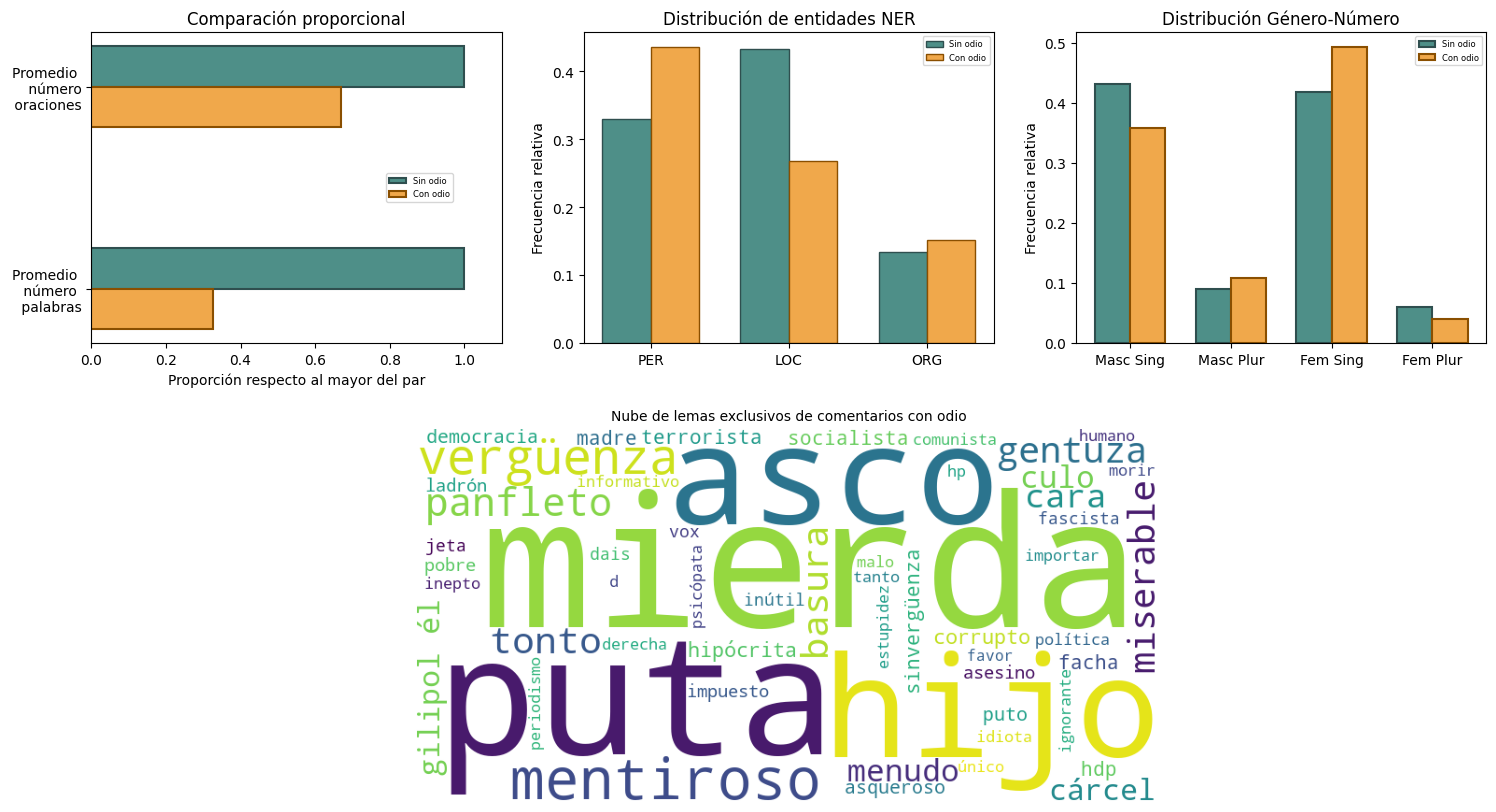

In [42]:
import os

# 1. Crear la carpeta si no existe (Buena práctica de ingeniería)
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)


fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[1, 1.2],
    hspace=0.25
)

# ================= FILA 1 =================
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

grafica_promedios(ax1)
grafica_ner(ax2)
grafica_gn(ax3)

# ================= FILA 2 =================
ax4 = fig.add_subplot(gs[1, :])
grafica_wordcloud(ax4)

# 2. Guardar la figura antes de plt.show()
# Usamos dpi=300 para alta resolución y bbox_inches='tight' para que no se corten los bordes
fig_path = os.path.join(output_dir, "dashboard_analisis_odio.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"Gráfica guardada en: {fig_path}")

plt.show()